# K-Means Clustering

In [1]:
#Hay que ejecutar esto antes para que no sé error
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

## Importing the libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [3]:
dataset = pd.read_csv('Mall_Customers.csv')
X = dataset.iloc[:, [3, 4]].values #Para coger las columnas "annual income" y "spending score"
#Usamos .iloc porque se trata de un dataset de numpy no un array de pandas

## Método del "codo" (elbow) para averiguar el número óptimo de clusters

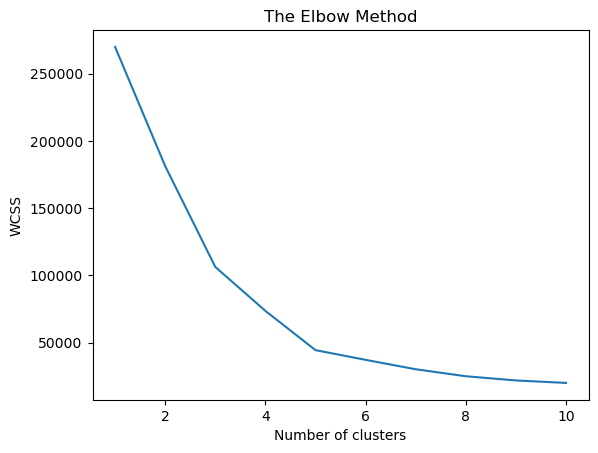

In [4]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter =300, random_state = 42, n_init=10)
    kmeans.fit(X) #calcula los centros geométricos de los clusters
    wcss.append(kmeans.inertia_) #inertia_-> Parámetro para la suma de los cuadrados de las distancias de los puntos al centro de cada cluster
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

El número óptimo de clusters sería 5

## Aplicar el método de K-means para segmentar el deta set

In [6]:
kmeans = KMeans(n_clusters = 5, init = 'k-means++', max_iter=300, n_init=10, random_state = 42)
y_kmeans = kmeans.fit_predict(X)

## Visualización de los clusters

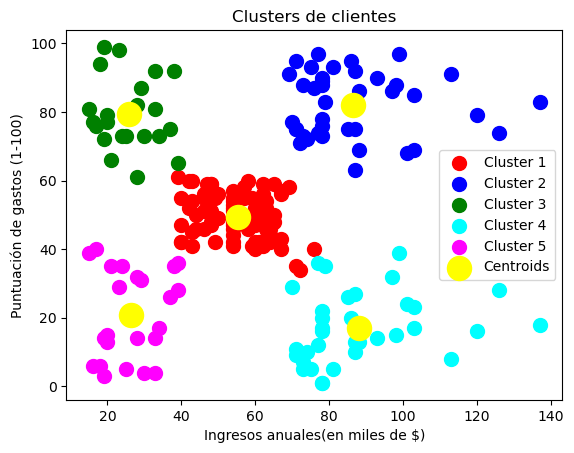

In [8]:
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s = 100, c = 'cyan', label = 'Cluster 4')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s = 100, c = 'magenta', label = 'Cluster 5')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids') #Para los baricentros
plt.title('Clusters de clientes')
plt.xlabel('Ingresos anuales(en miles de $)')
plt.ylabel('Puntuación de gastos (1-100)')
plt.legend()
plt.show()